In [103]:
!rm adult.data
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data -O adult.data

--2025-12-05 16:14:18--  https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘adult.data’

adult.data              [   <=>              ]   3.79M  7.10MB/s    in 0.5s    

2025-12-05 16:14:19 (7.10 MB/s) - ‘adult.data’ saved [3974305]



In [104]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import seaborn as sns

df = pd.read_csv('adult.data', header=None, na_values="?",    skipinitialspace=True)
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df.columns = column_names
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


(32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None
missing value each col: 
 age                  0
workclass         1836
fnlw

Text(0.5, 1.0, 'Correlation matrix (numeric features)')

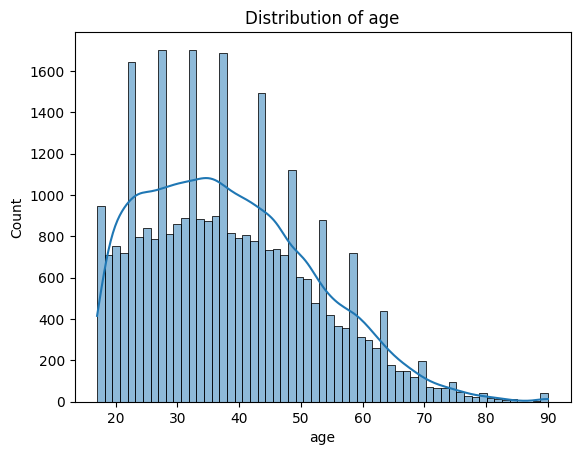

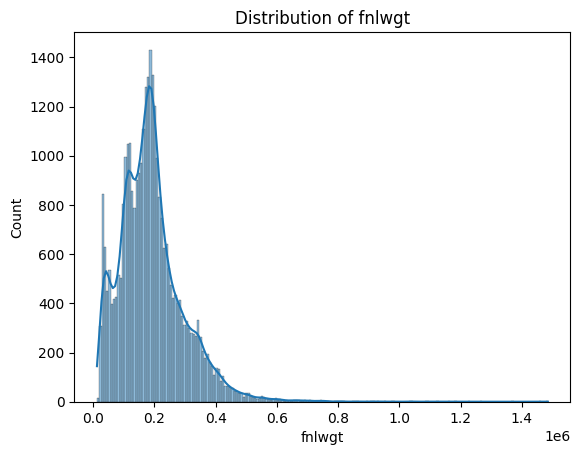

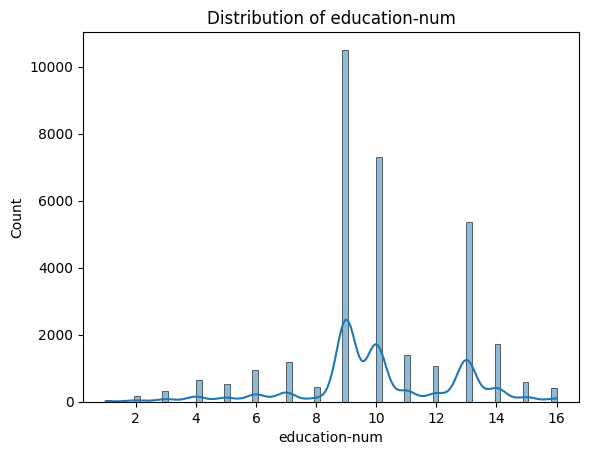

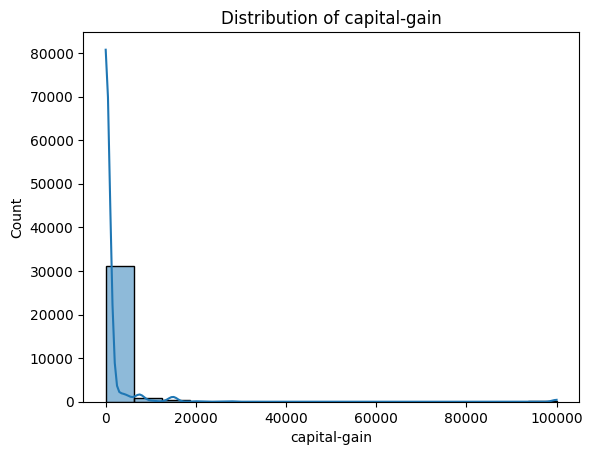

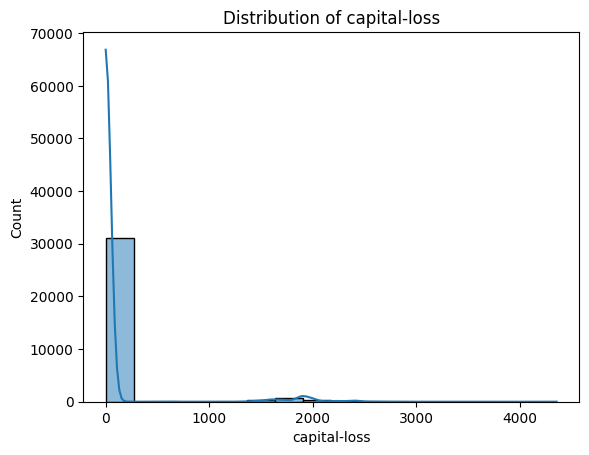

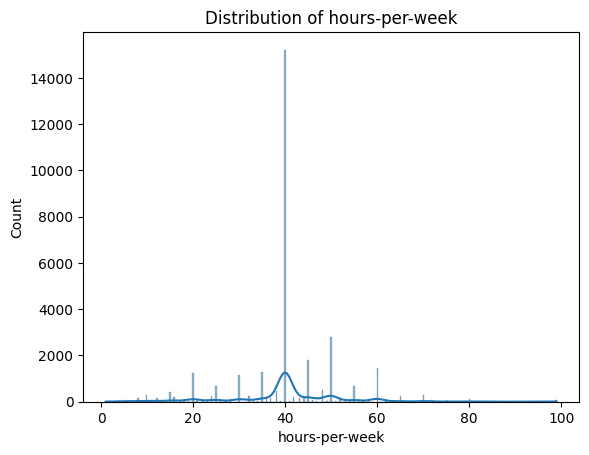

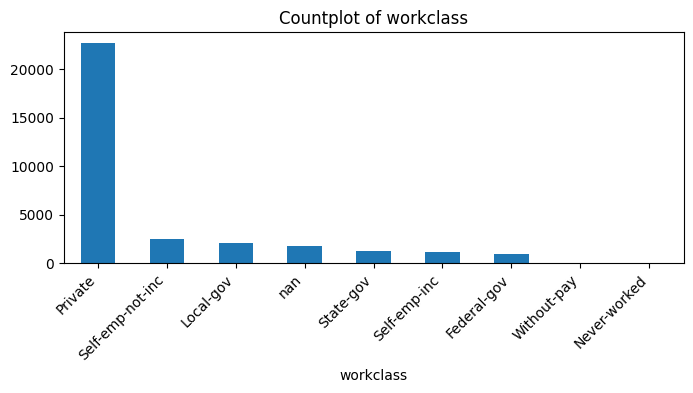

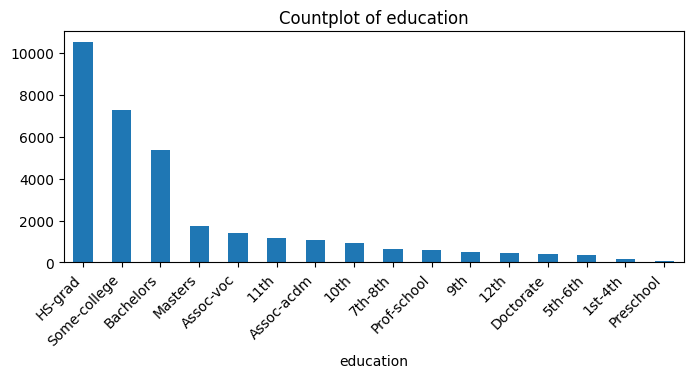

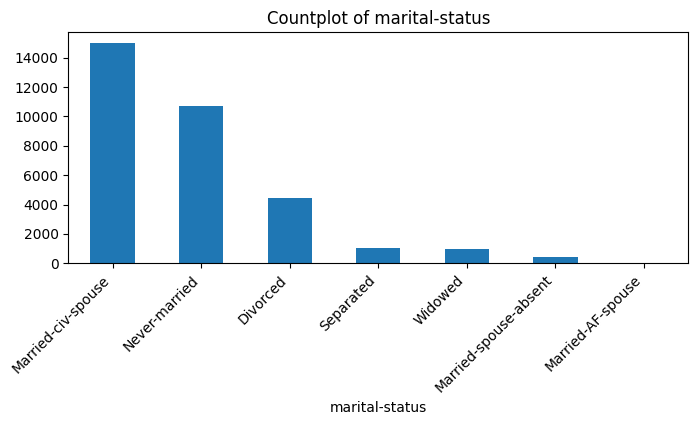

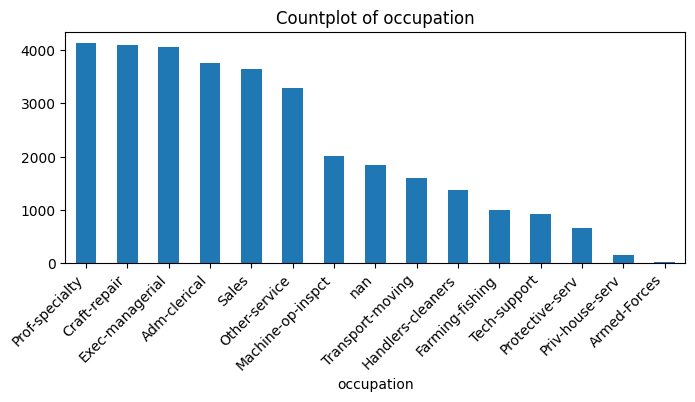

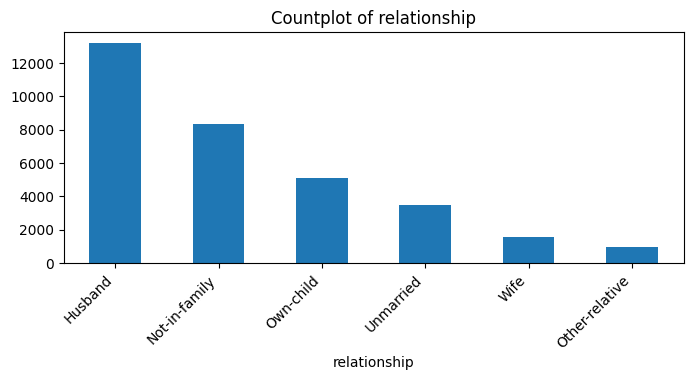

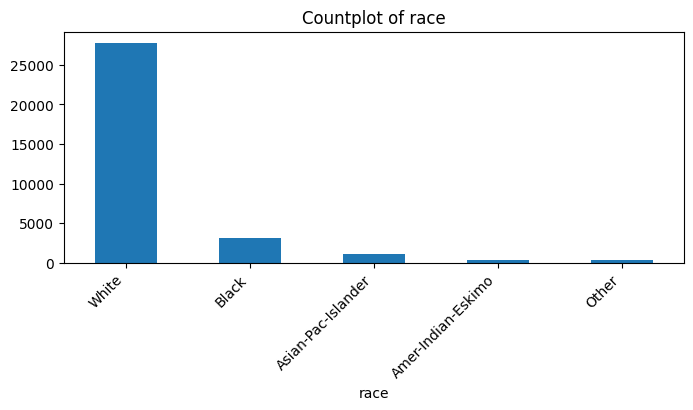

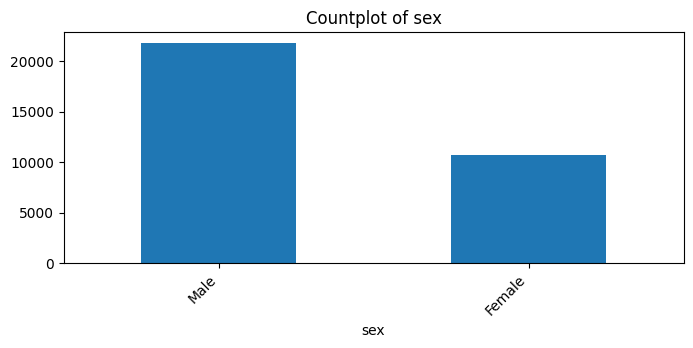

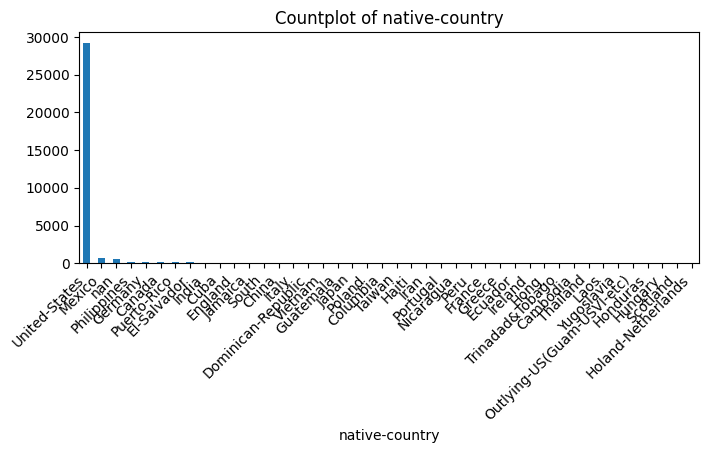

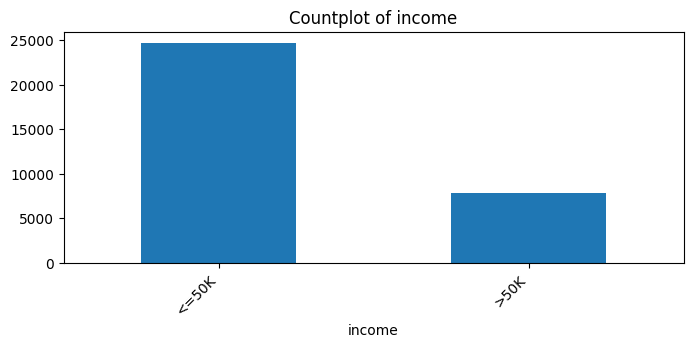

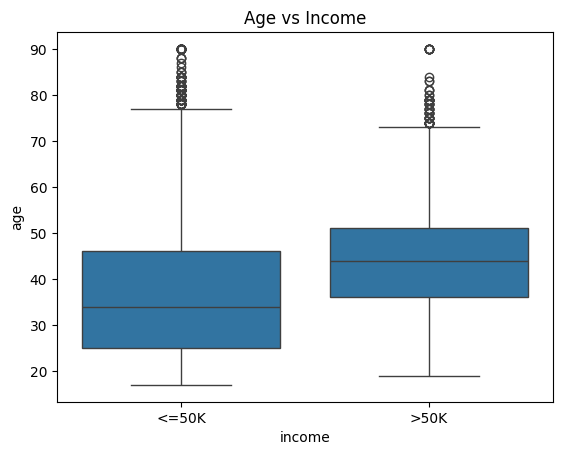

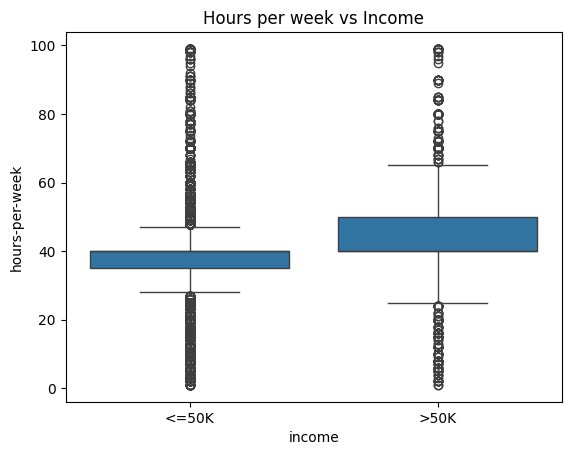

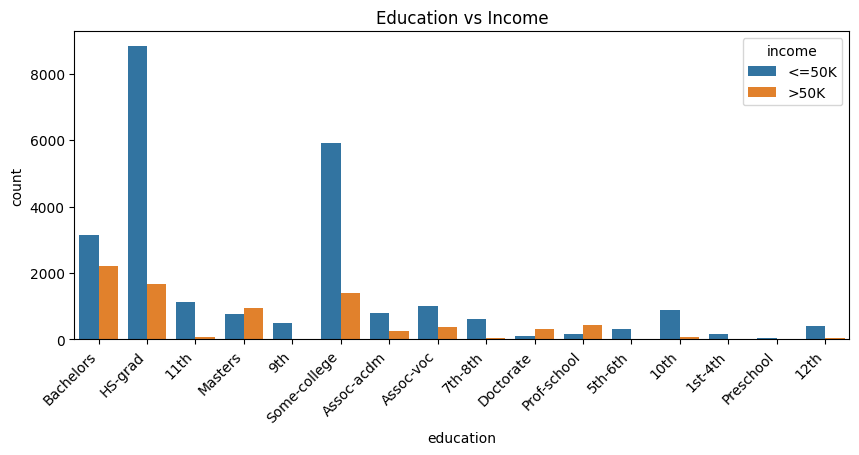

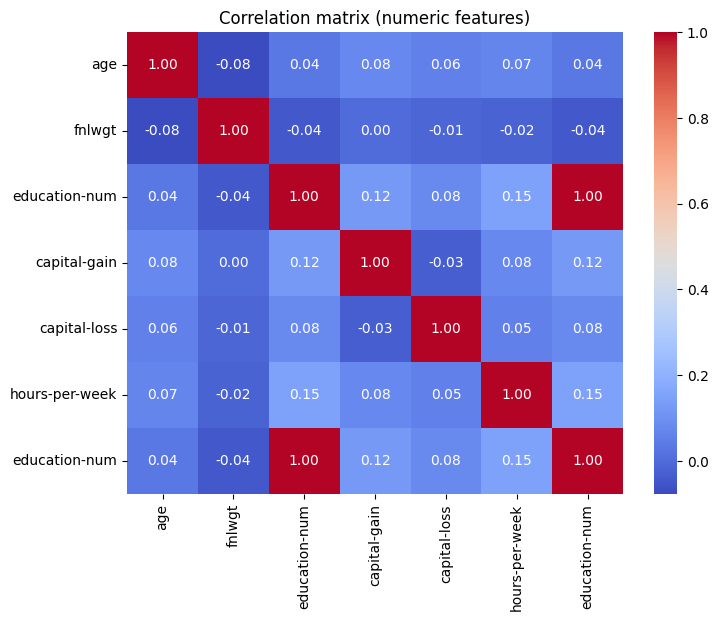

In [105]:

#EDA
#Tổng quan
print(df.shape)          # số dòng, cột
print(df.info())         # kiểu dữ liệu, non-null
print("missing value each col: \n", df.isna().sum())   # số missing mỗi cột
print(df.describe())     # thống kê cho các cột số
#Phân phối biến số
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')

#Phân phối biến phân loại
cat_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'sex', 'native-country', 'income']

for col in cat_cols:
    plt.figure(figsize=(8,3))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')

#
# age vs income
plt.figure()
sns.boxplot(x='income', y='age', data=df)
plt.title('Age vs Income')

# hours-per-week vs income
plt.figure()
sns.boxplot(x='income', y='hours-per-week', data=df)
plt.title('Hours per week vs Income')

# education vs income
plt.figure(figsize=(10,4))
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Education vs Income')

#
num_df = df[num_cols + ['education-num']]
corr = num_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix (numeric features)')



In [106]:

# Xử lý missing value
# print(df.isna().sum())
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [107]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
#normalization number variables
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

        age  workclass    fnlwgt  education  education-num  marital-status  \
0  0.030671          6 -1.063611          9       1.134739               4   
1  0.837109          5 -1.008707          9       1.134739               2   
2 -0.042642          3  0.245079         11      -0.420060               0   
3  1.057047          3  0.425801          1      -1.197459               2   
4 -0.775768          3  1.408176          9       1.134739               2   

   occupation  relationship  race  sex  capital-gain  capital-loss  \
0           0             1     4    1      0.148453      -0.21666   
1           3             0     4    1     -0.145920      -0.21666   
2           5             1     4    1     -0.145920      -0.21666   
3           5             0     2    1     -0.145920      -0.21666   
4           9             5     2    0     -0.145920      -0.21666   

   hours-per-week  native-country  income  
0       -0.035429              38       0  
1       -2.222153     

<Figure size 400x400 with 0 Axes>

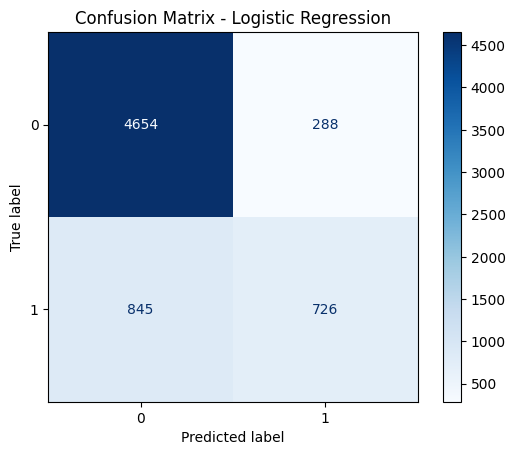

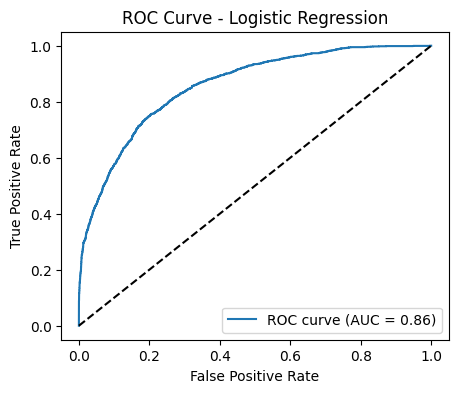

Model: Random Forest
Accuracy: 0.8609
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.75      0.64      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513



<Figure size 400x400 with 0 Axes>

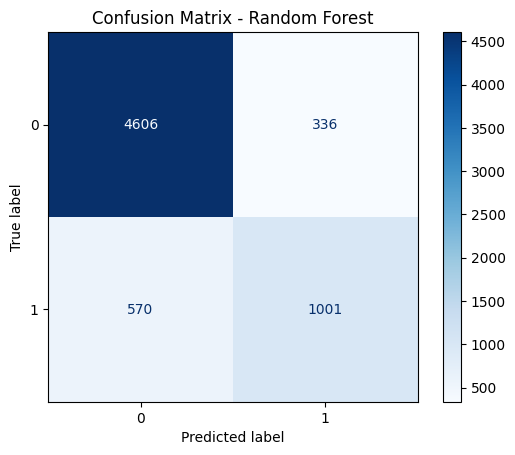

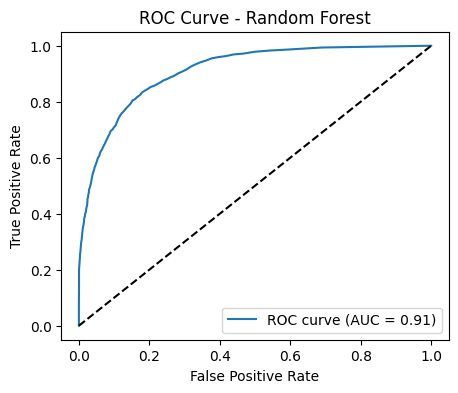

In [108]:

X = df.drop('income', axis=1)
y = df['income']
print(df.head())
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )
}

for name, clf in models.items():
    print("=" * 60)
    print(f"Model: {name}")
    clf.fit(X_train, y_train)

    # Dự đoán
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    plt.figure(figsize=(4, 4))
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # ROC curve
    if hasattr(clf, "predict_proba"):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test).ravel()

    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc='lower right')
    plt.show()


In [109]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_train_dl = y_train.values
y_test_dl  = y_test.values

input_dim = X_train.shape[1]

model_dl = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')   # nhị phân
])

model_dl.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

r = model_dl.fit(
    X_train,
    y_train_dl,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Evaluate test
y_prob = model_dl.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)


Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5844 - loss: 1.8258 - val_accuracy: 0.7574 - val_loss: 0.5739
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7108 - loss: 0.6657 - val_accuracy: 0.7626 - val_loss: 0.5242
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7498 - loss: 0.5384 - val_accuracy: 0.7756 - val_loss: 0.4671
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7649 - loss: 0.4890 - val_accuracy: 0.7939 - val_loss: 0.4251
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7787 - loss: 0.4574 - val_accuracy: 0.8129 - val_loss: 0.4085
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7902 - loss: 0.4430 - val_accuracy: 0.8244 - val_loss: 0.4021
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7945 - loss: 0.4321 - val_accuracy: 0.8251 - val_loss: 0.3894
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7966 - loss: 0.4272 - val_accuracy: 0.8296 - val_loss:

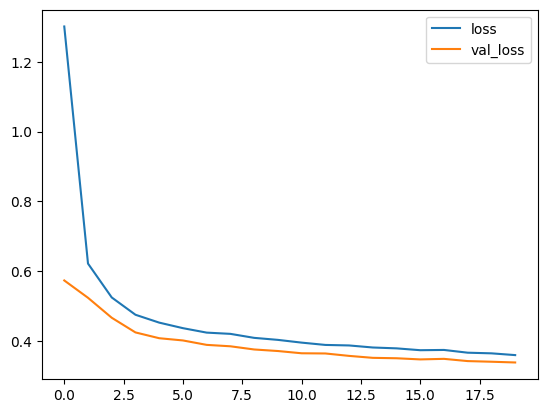

In [110]:
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

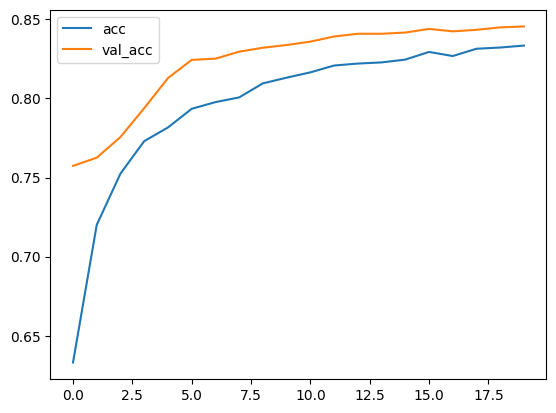

In [111]:
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

Accuracy: 0.8435436818670352
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4942
           1       0.77      0.50      0.61      1571

    accuracy                           0.84      6513
   macro avg       0.81      0.73      0.75      6513
weighted avg       0.84      0.84      0.83      6513



<Figure size 400x400 with 0 Axes>

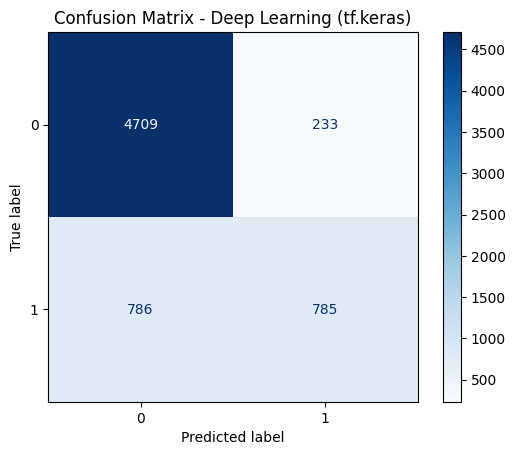

In [112]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Tính accuracy
acc = accuracy_score(y_test_dl, y_pred)
print("Accuracy:", acc)

# 3. In báo cáo phân loại
print(classification_report(y_test_dl, y_pred))

# 4. Confusion matrix
cm = confusion_matrix(y_test_dl, y_pred)

plt.figure(figsize=(4, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Deep Learning (tf.keras)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [116]:
#save the model
model_dl.save('model_dl.h5')